# Problem Statement - Option2 (Traffic Focus):
Develop a time-series machine learning model to forecast route-level travel delays and mean travel times in Banff for the next 1–3 hours.

Use route delay severity to identify bottlenecks.


# Block 1: Understanding Your Problem & Data

Objective
Forecast: Delay or mean travel time for each route for the next 1–3 hours.

Compare: Predicted vs. expected mean travel time.

Visualize: Hourly route-level delays on a map.

**Target Variables:**

mean travel time (mins) or actual delay (mins) (for forecasting)

**Key Features Available:**

calculation time (timestamp)

speed(km/h)

mean travel time (mins)

actual delay (mins)

current delay (mins)

route



In [1]:
import pandas as pd
df = pd.read_csv('cleaned_routes.csv')
df.head()

,Unnamed: 0,calculation time,speed(mph),speed(km/h),mean travel time (mins),actual delay (mins),current delay (mins),trend,route
0,0,2025-04-09 12:30:00,19.8,31.9,2.0,0.0,0.13,DOWN,Route 7
1,1,2025-04-09 12:29:00,19.8,31.9,2.0,0.0,0.13,DOWN,Route 7
2,2,2025-04-09 12:28:00,19.8,31.9,2.0,0.0,0.13,DOWN,Route 7
3,3,2025-04-09 12:27:00,19.8,31.9,2.0,0.0,0.13,DOWN,Route 7
4,4,2025-04-09 12:26:00,19.8,31.9,2.0,0.0,0.13,DOWN,Route 7


In [2]:
df.shape

(3617428, 9)

In [3]:
# Convert timestamp to date
df['date'] = pd.to_datetime(df['calculation time']).dt.date

# Group by route and calculate min and max date
date_range = df.groupby('route')['date'].agg(['min', 'max']).reset_index()

# Display the result
print(date_range)


       route         min         max
0    Route 1  2024-11-30  2025-02-10
1   Route 10  2024-11-30  2025-07-22
2   Route 11  2024-11-30  2025-07-22
3   Route 12  2024-11-30  2025-07-22
4   Route 13  2024-11-30  2025-07-22
5    Route 2  2024-11-30  2025-08-02
6    Route 3  2024-11-30  2025-02-10
7    Route 4  2024-11-30  2025-09-07
8    Route 5  2024-12-01  2025-09-07
9    Route 6  2024-12-01  2025-09-07
10   Route 7  2024-11-30  2025-08-02
11   Route 8  2024-11-30  2025-08-02


# Block 2: Time-Based Features

We extract temporal patterns using hour, day of week, weekend flag, and month. Lag features (e.g., t−1, t−2) and rolling averages (e.g., 3-hour window) help capture short-term trends in delay and travel time.


In [4]:
df['timestamp'] = pd.to_datetime(df['calculation time'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['month'] = df['timestamp'].dt.month


In [5]:
df = df.sort_values(by='timestamp')
df['lag_1h'] = df['mean travel time (mins)'].shift(1)
df['lag_2h'] = df['mean travel time (mins)'].shift(2)
df['rolling_avg_3h'] = df['mean travel time (mins)'].rolling(window=3).mean()

df = df.sort_values(by='timestamp')
df['delay_lag_1h'] = df.groupby('route')['actual delay (mins)'].shift(1)
df['delay_lag_2h'] = df.groupby('route')['actual delay (mins)'].shift(2)
df['rolling_delay_3h'] = df.groupby('route')['actual delay (mins)'].rolling(window=3).mean().reset_index(0, drop=True)


In [6]:
df.head()

,Unnamed: 0,calculation time,speed(mph),speed(km/h),mean travel time (mins),actual delay (mins),current delay (mins),trend,route,date,...,hour,day_of_week,is_weekend,month,lag_1h,lag_2h,rolling_avg_3h,delay_lag_1h,delay_lag_2h,rolling_delay_3h
3199354,3199354,2024-11-30 22:00:00,16.4,26.4,2.67,0.00,0.28,UP,Route 2,2024-11-30,...,22,5,1,11,NaN,NaN,NaN,NaN,NaN,NaN
1245809,1245809,2024-11-30 22:00:00,21.9,35.3,7.50,0.25,0.57,FLAT,Route 11,2024-11-30,...,22,5,1,11,2.67,NaN,NaN,NaN,NaN,NaN
1834020,1834020,2024-11-30 22:00:00,25.8,41.5,5.40,0.00,0.63,FLAT,Route 1,2024-11-30,...,22,5,1,11,7.50,2.67,5.19,NaN,NaN,NaN
2218944,2218944,2024-11-30 22:00:00,12.7,20.4,2.88,0.22,0.25,FLAT,Route 4,2024-11-30,...,22,5,1,11,5.40,7.50,5.26,NaN,NaN,NaN
980211,980211,2024-11-30 22:00:00,11.7,18.8,3.33,0.00,0.07,FLAT,Route 8,2024-11-30,...,22,5,1,11,2.88,5.40,3.87,NaN,NaN,NaN


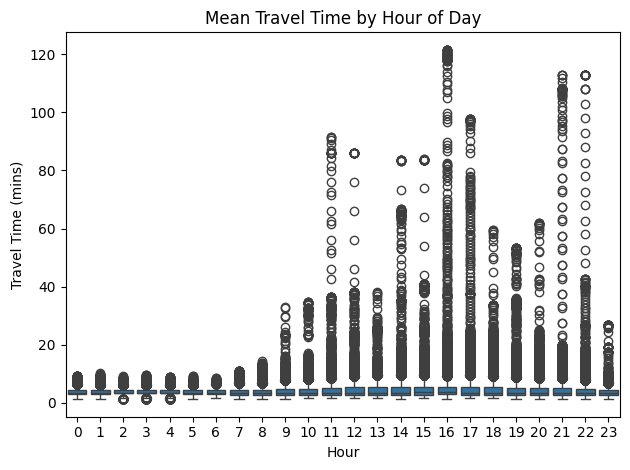

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

#Box Plot of Mean Travel Time by Hour
sns.boxplot(data=df, x='hour', y='mean travel time (mins)')
plt.title('Mean Travel Time by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Travel Time (mins)')
plt.tight_layout()
plt.show()


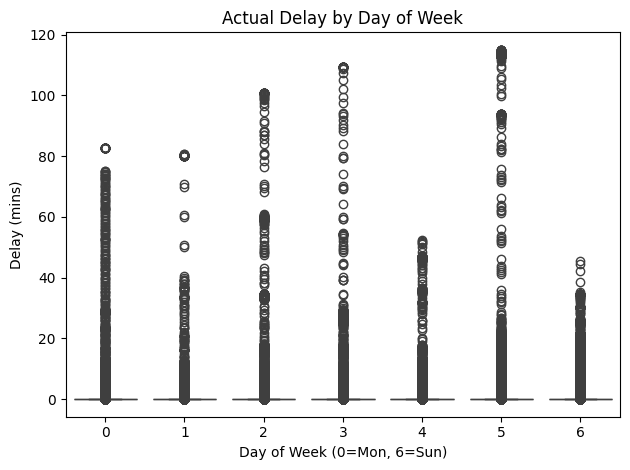

In [8]:
#Box Plot of Actual Delay by Day of Week
sns.boxplot(data=df, x='day_of_week', y='actual delay (mins)')
plt.title('Actual Delay by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Delay (mins)')
plt.tight_layout()
plt.show()


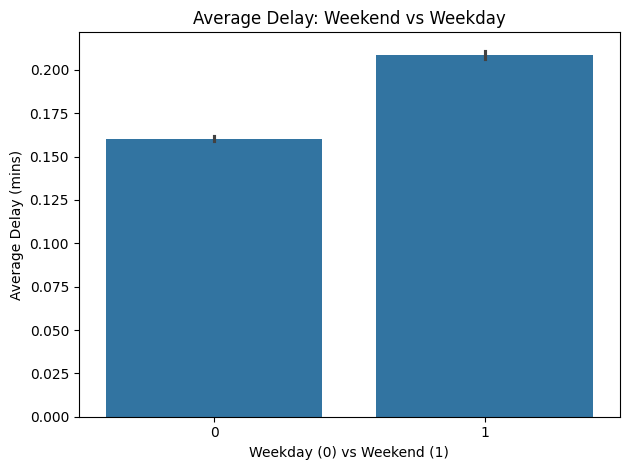

In [9]:
import numpy as np

#Bar Plot: Weekend vs Weekday Delay
sns.barplot(data=df, x='is_weekend', y='actual delay (mins)', estimator=np.mean)
plt.title('Average Delay: Weekend vs Weekday')
plt.xlabel('Weekday (0) vs Weekend (1)')
plt.ylabel('Average Delay (mins)')
plt.tight_layout()
plt.show()

# Block 3: Traffic-Based Features

We classify delays by comparing actual delay vs. expected mean travel time. Aggregated features like hourly delay rate per route and rolling averages help identify congestion trends and forecast future delays


In [10]:
# Filter out rows where any of the target columns are zero
filtered_df = df[
    (df['mean travel time (mins)'] > 0) &
    (df['actual delay (mins)'] > 0) &
    (df['current delay (mins)'] > 0)
]

# Group by route and calculate mean
route_averages = filtered_df.groupby('route')[[
    'mean travel time (mins)',
    'actual delay (mins)',
    'current delay (mins)'
]].mean().reset_index()

# Display result
print(route_averages)


       route  mean travel time (mins)  actual delay (mins)  \
0    Route 1                 6.652001             0.652001   
1   Route 10                 9.067071             1.817071   
2   Route 11                 8.160176             0.910176   
3   Route 12                 5.927343             1.510741   
4   Route 13                 5.526389             1.109832   
5    Route 2                 4.529257             1.029257   
6    Route 3                 6.093377             0.426888   
7    Route 4                 3.109585             0.443037   
8    Route 5                 4.494054             0.827505   
9    Route 6                 3.550194             0.408820   
10   Route 7                 4.272109             0.938794   
11   Route 8                 5.452863             2.119604   

    current delay (mins)  
0               1.151417  
1               3.228136  
2               1.318307  
3               2.064148  
4               1.461889  
5               1.230654  
6   

In [11]:
# Filter out rows with zero mean travel time
filtered_df = df[df['mean travel time (mins)'] > 0]

# Compute route-level average from filtered data
route_avg = filtered_df.groupby('route')['mean travel time (mins)'].mean()

# Map back to original DataFrame
df['route_avg_travel_time'] = df['route'].map(route_avg)


In [12]:
# Delay classification
df['delay_flag'] = (df['mean travel time (mins)'] > df['route_avg_travel_time']).astype(int)

# Hourly route delay summary
hourly_delay = df.groupby(['route', df['timestamp'].dt.hour])['delay_flag'].mean().reset_index(name='delay_rate')


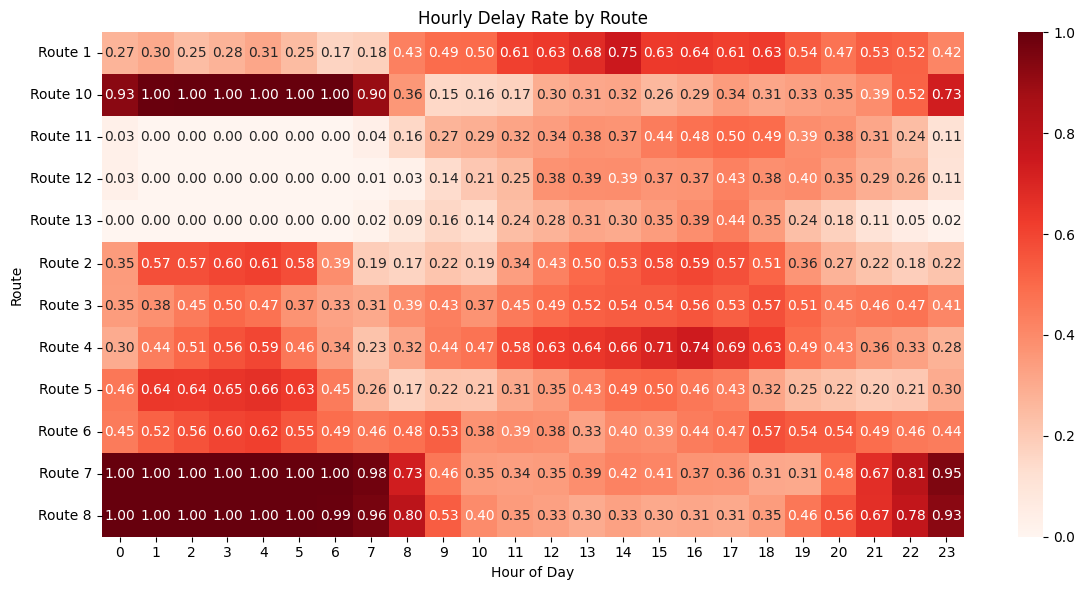

In [13]:
# Pivot for heatmap
heatmap_data = hourly_delay.pivot(index='route', columns='timestamp', values='delay_rate')

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt=".2f")
plt.title('Hourly Delay Rate by Route')
plt.xlabel('Hour of Day')
plt.ylabel('Route')
plt.tight_layout()
plt.show()


# Block 5: Feature Relationships

We analyze correlations between speed, delay, and travel time using heatmaps and scatter plots. This helps identify which features are most predictive and guides feature selection for modeling.


<Axes: >

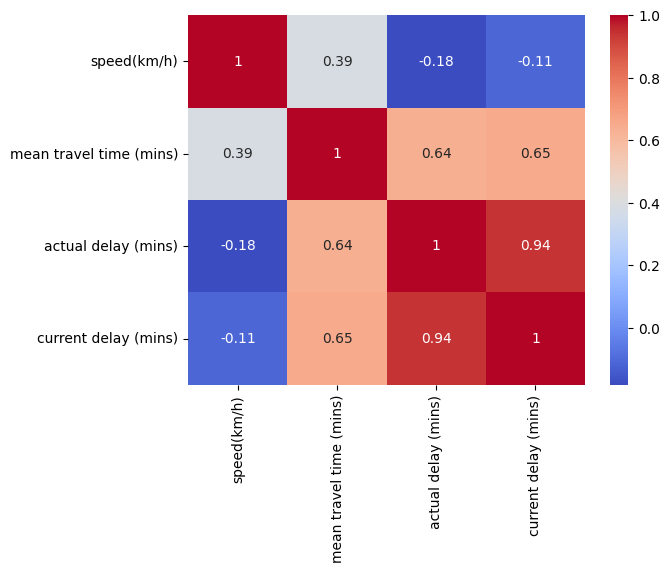

In [14]:
import seaborn as sns
corr = df[['speed(km/h)', 'mean travel time (mins)', 'actual delay (mins)', 'current delay (mins)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


Obviously, the Actual delay and current delay are very closely related, with a strong correlation of 0.94, since they have the same trend.

Mean travel time also has a moderate positive relationship with both delay metrics, around 0.63 to 0.64, suggesting that longer travel times often come with higher delays.

Speed is moderately linked to travel time (0.55), which makes sense as the faster speeds usually mean shorter trips. However, speed has only a weak connection to delays (−0.12), indicating that other factors likely play a bigger role in causing congestion.

<Axes: xlabel='speed(km/h)', ylabel='actual delay (mins)'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


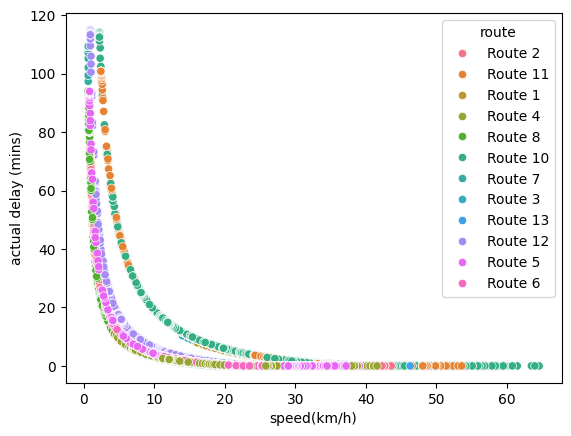

In [15]:
sns.scatterplot(data=df, x='speed(km/h)', y='actual delay (mins)', hue='route')


This scatter plot reveals a clear inverse relationship between speed and actual delay across Banff routes: as vehicle speed increases, delays tend to decrease.

# Block 4: Geospatial Visualization

We use route coordinates to visualize delays on a map. Routes with high delay rates at specific hours are highlighted using folium, helping pinpoint spatial bottlenecks in Banff.


In [67]:
pip install googlemaps folium

In [68]:
import googlemaps

# Google maps API
api_key = 'YOUR_API_KEY'
gmaps = googlemaps.Client(key=api_key)

In [69]:
# Compute delay rate per route (e.g., for a specific hour)
target_hour = 15
delay_df = df[df['timestamp'].dt.hour == target_hour].groupby('route')['delay_flag'].mean().reset_index(name='delay_rate')


In [70]:
coords_dict = {
    'Route 1': [(51.1516, -115.5594), (51.1802, -115.5657)],  # Rimrock Hotel to Downtown
    'Route 2': [(51.1644, -115.5619), (51.1802, -115.5657)],  # Banff Springs Hotel to Downtown
    'Route 3': [(51.1802, -115.5657), (51.1516, -115.5594)],  # Downtown to Rimrock Hotel
    'Route 4': [(51.1802, -115.5657), (51.1644, -115.5619)],  # Downtown to Banff Springs
    'Route 5': [(51.1690, -115.5915), (51.1802, -115.5657)],  # Cave Avenue to Downtown
    'Route 6': [(51.1802, -115.5657), (51.1690, -115.5915)],  # Downtown to Cave Avenue
    'Route 7': [(51.1762, -115.5698), (51.1802, -115.5657)],  # West Entrance to Downtown
    'Route 8': [(51.1802, -115.5657), (51.1762, -115.5698)],  # Downtown to West Entrance
    'Route 10': [(51.1802, -115.5657), (51.1830, -115.5500)], # Downtown to East Entrance (approx)
    'Route 11': [(51.1830, -115.5500), (51.1802, -115.5657)], # East Entrance to Downtown
    'Route 12': [(51.1802, -115.5657), (51.1850, -115.5571)], # Downtown to Inns of Banff Hotel
    'Route 13': [(51.1850, -115.5571), (51.1802, -115.5657)]  # Inns of Banff Hotel to Downtown
}


In [71]:
def get_route_polyline(start, end):
    directions = gmaps.directions(start, end, mode='driving')
    encoded_polyline = directions[0]['overview_polyline']['points']
    return googlemaps.convert.decode_polyline(encoded_polyline)


In [72]:
import folium

banff_map = folium.Map(location=[51.1784, -115.5708], zoom_start=14)

for route, (start, end) in coords_dict.items():
    polyline = get_route_polyline(start, end)
    folium.PolyLine(locations=[(p['lat'], p['lng']) for p in polyline],
                    color='red', weight=5,
                    popup=f"{route}").add_to(banff_map)

banff_map.save('banff_google_routes.html')


In [73]:
banff_map


In [77]:
import folium

# Initialize map
banff_map = folium.Map(location=[51.1784, -115.5708], zoom_start=14)

# Add polylines and midpoint markers with delay info
for _, row in delay_df.iterrows():
    route = row['route']
    delay_rate = row['delay_rate']

    if route in coords_dict:
        start_coords, end_coords = coords_dict[route]

        # Add route polyline
        folium.PolyLine(
            locations=[start_coords, end_coords],
            color='red' if delay_rate > 0.5 else 'green',
            weight=5,
            popup=f"{route}: Delay Rate = {delay_rate:.2f}"
        ).add_to(banff_map)

        # Add midpoint marker with delay info
        mid_lat = (start_coords[0] + end_coords[0]) / 2
        mid_lon = (start_coords[1] + end_coords[1]) / 2
        folium.Marker(
            location=[mid_lat, mid_lon],
            popup=f"{route}\nDelay Rate: {delay_rate:.2f} at {target_hour}:00",
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(banff_map)

# Display the map inline
banff_map
